# Home Safety Risk Ranking — Simplified Learner Recipe
## ADAPTED FOR STATION GROUND   LEVEL

This notebook guides you through building a **risk-ranking model** for the home-safety dataset.

The goal is **not** to create a perfect yes/no classifier. The goal is to sort records from highest risk to lowest risk so that the top records contain more true incidents than we would get by random selection.

This is important because the target is imbalanced. When positives are rare, accuracy and a default 0.5 threshold can be misleading. Here we care about questions like:

- If we inspect the **top 50** highest-risk records, how many true incidents do we capture?
- Is the top 50 list better than random selection?
- Would top 100 or top 200 be more realistic operationally?

This simplified version focuses on **one model family: Random Forest**.

## Before you start

You only need to make a small number of decisions:

1. Update the data file path.
2. Confirm the target column name.
3. Check the target is correctly encoded as 0/1.
4. Review the list of columns removed from modelling to avoid leakage.
5. Run the RandomizedSearchCV section and interpret the top-K results.

Avoid changing too many things at once. Get the notebook running first, then improve it.

## 1. Imports

Run this cell first. It loads the packages needed for the workflow.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import randint

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import sklearn.ensemble

## 2. Simple configuration

Update only the values in this cell.

The most important settings are:

- `DATA_PATH`: where the dataset is saved.
- `TARGET_RAW`: the original target column in the dataset.
- `TOP_K_VALUES`: the ranked list sizes to evaluate.

In [2]:
# TODO 1: update this path to match where your dataset is saved.
#DATA_PATH = Path("df_new.xlsx")
#DATA_PATH = Path("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/df_new.xlsx")
#DATA_PATH = Path("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/Household_data/RESIDENTIAL_OXON_anon.xlsx")
DATA_PATH = Path("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/OXON_HH_DATA.xlsx")

# TODO 2: confirm this is the correct target column in your dataset.
TARGET_RAW = "Incident?"


# This will be the cleaned 0/1 target column used for modelling.
TARGET = "target_incident"

# These are the ranked list sizes we want to evaluate.
# Keep this simple at first.
TOP_K_VALUES = [50, 100, 200, 500]

# Random seed so results are reproducible.
RANDOM_STATE = 42

# Data split sizes.
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAIN = 0.25

# Random search size.
# Start with 25. Increase later if the notebook runs quickly.
# on my lap top the fitting process takes an exceedingly long time
# ... feel free to amend as per processing time of your system
N_ITER_SEARCH = 5

# Cross-validation folds.## 5 originally
CV_SPLITS = 5

## 3. Load the data

This cell tries to load Excel, CSV, or Parquet files.

After loading, check:

- the number of rows and columns;
- whether the target column exists;
- whether the first few rows look sensible.

### Outputs the dataframe named "df_raw"

In [3]:
def load_tabular_data(path: Path) -> pd.DataFrame:
    """Load a tabular dataset from Excel, CSV, or Parquet."""
    suffix = path.suffix.lower()
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {suffix}")


df_raw = load_tabular_data(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head(2))

print("\nColumns:")
print(df_raw.columns.tolist())

Dataset shape: (301489, 22)


,s,ABP_Classification_Code,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,...,(H) Mosaic UK 7 Type,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,LSOA11CD,Incident?
0,100120859623,RD04,Terraced,N,10,1.0,0,3,12.0,11,...,22,F22 Boomerang Boarders,13,0,N,0,2,JX32,E01028635,N
1,10002188486,RD02,Detached,N,11,1.0,0,4,12.0,11,...,10,C10 Wealthy Landowners,19,0,N,0,8,JX12,E01028762,N



Columns:
['s', 'ABP_Classification_Code', 'ABP_Classification_Desc', 'Communal Household Flag', '(H) Age - Fine', '(H) Household Composition', '(H) Presence of Elderly Parent', '(H) Number of Adults in Household', '(H) Family Lifestage v3', '(H) Length of Residency', '(H) Property Type 2011', '(H) Tenure 2011', '(H) Mosaic UK 7 Type', '(H) Mosaic UK 7 Type Label', '(H) Affluence v2', '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag', '(H) Number of Children v3', '(H) Household Income v3 - Bands', 'Station_Ground_Code', 'LSOA11CD', 'Incident?']


In [4]:
df_raw.rename(columns = {'s':'Addressbase UPRN','irs.Incident?':'Incident?'}, inplace =True)

# after seeing correlation between 'ABP...' and '(H) Property...' being 0.84
### see Fire_recipe_Multi Collinearity.ipynb for details
df_raw.drop(columns = ['ABP_Classification_Code','(H) Mosaic UK 7 Type','(H) Property Type 2011'], inplace = True) 

# COLLINEARITY(['ABP_Classification_Desc'] ,['(H) Property Type 2011']) >>> 0.848508
df_raw.head(2)

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,LSOA11CD,Incident?
0,100120859623,Terraced,N,10,1.0,0,3,12.0,11,0,F22 Boomerang Boarders,13,0,N,0,2,JX32,E01028635,N
1,10002188486,Detached,N,11,1.0,0,4,12.0,11,0,C10 Wealthy Landowners,19,0,N,0,8,JX12,E01028762,N


## (added on 14/7/2026)
### Convert the following columns into boolean format:


In [5]:
df_raw[['(H) Fuel Poverty v2 Flag','(H) Presence of Elderly Parent','(H) Water Poverty Flag','Communal Household Flag']].info()

<class 'pandas.DataFrame'>
RangeIndex: 301489 entries, 0 to 301488
Data columns (total 4 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   (H) Fuel Poverty v2 Flag        301489 non-null  str  
 1   (H) Presence of Elderly Parent  301489 non-null  int64
 2   (H) Water Poverty Flag          301489 non-null  int64
 3   Communal Household Flag         301489 non-null  str  
dtypes: int64(2), str(2)
memory usage: 9.2 MB


In [6]:
df_raw[['(H) Fuel Poverty v2 Flag',
        '(H) Presence of Elderly Parent',
        '(H) Water Poverty Flag','Communal Household Flag']] = df_raw[['(H) Fuel Poverty v2 Flag',
                                                                       '(H) Presence of Elderly Parent',
                                                                       '(H) Water Poverty Flag',
                                                                       'Communal Household Flag']].astype('bool')

In [7]:
df_raw[['(H) Fuel Poverty v2 Flag','(H) Presence of Elderly Parent','(H) Water Poverty Flag','Communal Household Flag']].info()

<class 'pandas.DataFrame'>
RangeIndex: 301489 entries, 0 to 301488
Data columns (total 4 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   (H) Fuel Poverty v2 Flag        301489 non-null  bool 
 1   (H) Presence of Elderly Parent  301489 non-null  bool 
 2   (H) Water Poverty Flag          301489 non-null  bool 
 3   Communal Household Flag         301489 non-null  bool 
dtypes: bool(4)
memory usage: 1.2 MB


# STATION GROUND CODE
### Reducing sample size to Station Ground Region as per users selection.
#### Here is the choice

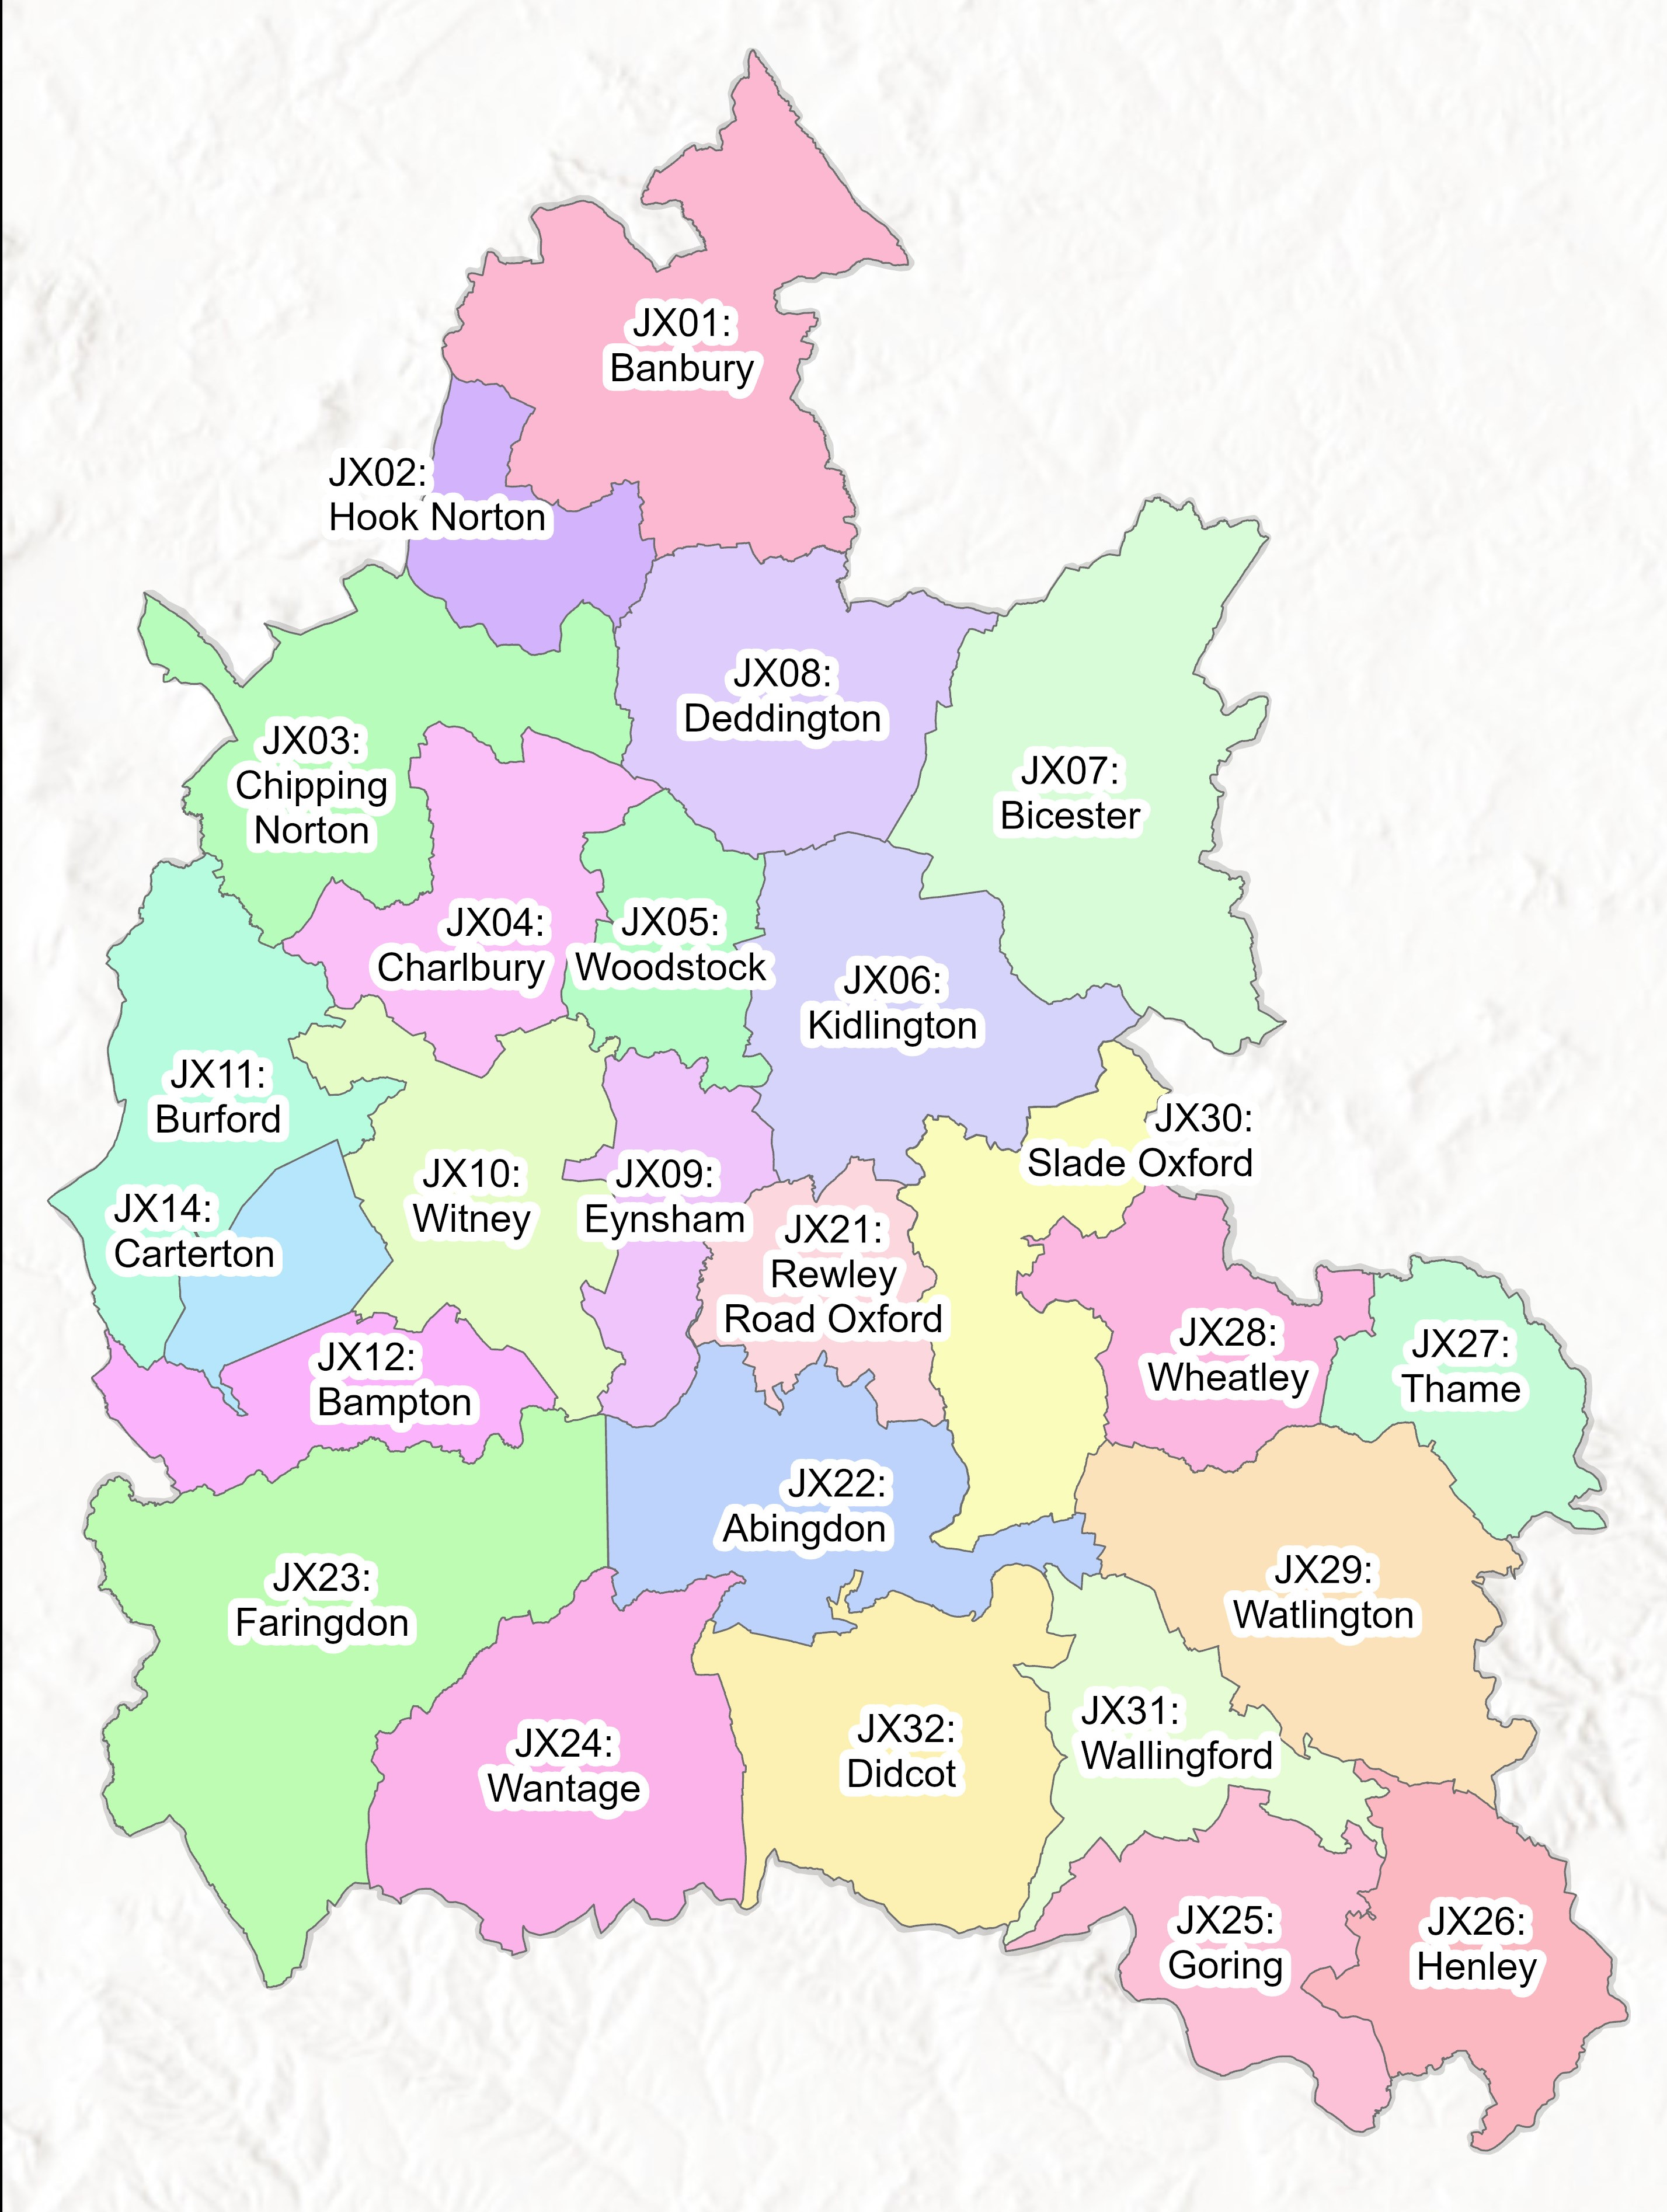

In [8]:
from IPython.display import Image
Image(filename='C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/Documents for June 2026/images/STATION_REGION_MAP.jpg',width=400, height=200)

In [9]:
station_hh_count = df_raw['Station_Ground_Code'].value_counts()
Station_Ground_List = pd.read_csv('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/Documents for June 2026/STATION_GeoLocs.csv')
Station_Ground_List = Station_Ground_List[['Station Ground Name','Station Ground Code']].merge(station_hh_count, left_on = 'Station Ground Code', right_on = 'Station_Ground_Code')
Station_Ground_List

,Station Ground Name,Station Ground Code,count
0,Banbury,JX01,34979
1,Hook Norton,JX02,2252
2,Chipping Norton,JX03,5500
3,Charlbury,JX04,3047
4,Woodstock,JX05,3563
5,Kidlington,JX06,12315
6,Bicester,JX07,23165
7,Deddington,JX08,5277
8,Eynsham,JX09,5150
9,Witney,JX10,16799


In [10]:
Station_Ground_Code='JX06'

# The region of Oxford City includes two Station Grounds, therefore use the following OR condition:
#df_raw = df_raw[(df_raw['Station_Ground_Code']== 'JX21') | (df_raw['Station_Ground_Code'] == "JX30")]

df_raw = df_raw[df_raw['Station_Ground_Code']==Station_Ground_Code]
df_raw.shape
df_raw[['Station_Ground_Code','Incident?']].value_counts()

Station_Ground_Code  Incident?
JX06                 N            12239
                     Y               76
Name: count, dtype: int64

In [11]:
df_raw['Station_Ground_Code'].value_counts() 

Station_Ground_Code
JX06    12315
Name: count, dtype: int64

## 4. Clean the target

The model needs the target to be numeric:

- `1` = incident / positive case;
- `0` = no incident / negative case.

Check the printed value counts carefully. If the mapping is wrong, fix it before continuing.

In [12]:
def clean_binary_target(series: pd.Series) -> pd.Series:
    """Convert a Yes/No or 0/1 target into clean integer 0/1 values."""
    # If already numeric 0/1, keep it simple.
    numeric = pd.to_numeric(series, errors="coerce")
    non_missing_numeric = numeric.dropna()
    if len(non_missing_numeric) > 0 and set(non_missing_numeric.unique()).issubset({0, 1}):
        return numeric.astype("Int64")

    # Otherwise use a conservative string mapping.
    normalised = series.astype(str).str.strip().str.lower()

    positive_values = {"yes", "y", "Y", "true", "1", "incident", "fire"}
    negative_values = {"no", "n", "N", "false", "0", "none", "no incident", "not incident"}

    mapped = normalised.map(lambda x: 1 if x in positive_values else 0 if x in negative_values else np.nan)
    return mapped.astype("Int64")


print("Original target values:")
display(df_raw[TARGET_RAW].value_counts(dropna=False))

# Create modelling dataframe.
df = df_raw.copy()

################################################################################################

df[TARGET] = clean_binary_target(df[TARGET_RAW])

# Drop rows where the target could not be mapped.
before = len(df)
df = df.dropna(subset=[TARGET]).copy()
df[TARGET] = df[TARGET].astype(int)
after = len(df)

print(f"Rows before target cleaning: {before}")
print(f"Rows after target cleaning:  {after}")

print("\nCleaned target values:")
display(df[TARGET].value_counts(dropna=False).to_frame("count"))

Original target values:


Incident?
N    12239
Y       76
Name: count, dtype: int64

Rows before target cleaning: 12315
Rows after target cleaning:  12315

Cleaned target values:


,count
target_incident,
0,12239
1,76


## 5. Check class imbalance

This tells us how rare the positive class is.

If the positive class is rare, a model can have high accuracy while still being useless. That is why this notebook focuses on ranking metrics instead.

In [13]:
target_summary = df[TARGET].value_counts().sort_index().to_frame("count")
target_summary["proportion"] = target_summary["count"] / target_summary["count"].sum()
display(target_summary)

positive_rate = df[TARGET].mean()
print(f"Baseline positive rate: {positive_rate:.2%}")
print("This is the approximate success rate expected from random selection.")

,count,proportion
target_incident,,
0,12239,0.993829
1,76,0.006171


Baseline positive rate: 0.62%
This is the approximate success rate expected from random selection.


## 6. Choose feature columns and avoid leakage

Some columns should not be used as model features.

Common examples:

- unique identifiers;
- post-incident information;
- columns that directly reveal the target;
- columns only known after the incident has happened;
- raw coordinate columns, unless you can justify their use.

The columns removed from modelling can still be kept later in the ranked output so the organisation can identify the records.

In [14]:
# TODO 3: Review this list. Add/remove columns based on your dataset.
# These columns will NOT be used as model features.
DROP_COLUMNS_AS_FEATURES = [
    TARGET_RAW,
    TARGET,
    "Addressbase UPRN",
 
    "Unnamed: 0",
    "Easting",
    "Northing",
    "FRSIncidentIdentifier",
    "IncidentCategory",
    "VictimsInvolved",
    "VictimType",
    "WasRescued",
     "LSOA11CD"
]

# These columns are useful for the final ranked output, if they exist.
ID_COLUMNS_FOR_OUTPUT = [
    "Addressbase UPRN",
    "Easting",
    "Northing",
    "LSOA11CD",
    "Property_Type",
    "Property_Description",
]

feature_columns = [
    col for col in df.columns
    if col not in DROP_COLUMNS_AS_FEATURES
]

id_columns = [
    col for col in ID_COLUMNS_FOR_OUTPUT
    if col in df.columns
]

print(f"Number of feature columns: {len(feature_columns)}")
print("\nFeature columns used by the model:")
print(feature_columns)

print("\nID/context columns kept for ranked output:")
print(id_columns)


Number of feature columns: 16

Feature columns used by the model:
['ABP_Classification_Desc', 'Communal Household Flag', '(H) Age - Fine', '(H) Household Composition', '(H) Presence of Elderly Parent', '(H) Number of Adults in Household', '(H) Family Lifestage v3', '(H) Length of Residency', '(H) Tenure 2011', '(H) Mosaic UK 7 Type Label', '(H) Affluence v2', '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag', '(H) Number of Children v3', '(H) Household Income v3 - Bands', 'Station_Ground_Code']

ID/context columns kept for ranked output:
['Addressbase UPRN', 'LSOA11CD']


## 7. Split the data

We use three sets:

- **Train**: fit the model and tune hyperparameters.
- **Validation**: compare the tuned model and inspect ranking performance.
- **Test**: final honest evaluation, used only once at the end.

Because the target is imbalanced, we use stratified splits so each set has a similar positive rate.

In [15]:
X = df[feature_columns].copy()
X.info()

<class 'pandas.DataFrame'>
Index: 12315 entries, 52 to 300191
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ABP_Classification_Desc            12315 non-null  str    
 1   Communal Household Flag            12315 non-null  bool   
 2   (H) Age - Fine                     12315 non-null  int64  
 3   (H) Household Composition          12249 non-null  float64
 4   (H) Presence of Elderly Parent     12315 non-null  bool   
 5   (H) Number of Adults in Household  12315 non-null  int64  
 6   (H) Family Lifestage v3            12249 non-null  float64
 7   (H) Length of Residency            12315 non-null  int64  
 8   (H) Tenure 2011                    12315 non-null  int64  
 9   (H) Mosaic UK 7 Type Label         12315 non-null  str    
 10  (H) Affluence v2                   12315 non-null  int64  
 11  (H) Water Poverty Flag             12315 non-null  bool   
 12  (H) 

In [16]:
X = df[feature_columns].copy() 
y = df[TARGET].copy()

ids = df[id_columns].copy() if id_columns else pd.DataFrame(index=df.index)


# First split: train+validation vs test.
X_train_val, X_test, y_train_val, y_test, ids_train_val, ids_test = train_test_split(
    X,
    y,
    ids,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Second split: train vs validation.
X_train, X_valid, y_train, y_valid, ids_train, ids_valid = train_test_split(
    X_train_val,
    y_train_val,
    ids_train_val,
    test_size=VALIDATION_SIZE_WITHIN_TRAIN,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rows": [len(y_train), len(y_valid), len(y_test)],
    "positives": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "positive_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
}, index=["train", "validation", "test"])

display(split_summary)

# ---------------------
## FUTURE IMPROVEMENT:
# ---------------------
### If computational Power is not an issue, then the following improvemnets can be made:
## save a regional X_test, y_test into csv for holding.
#### bring this test set in later to compare with full data version

## We shall have two models: one full set and one filter subset
### run evaluation metrics >> choose the best version
#### impossible to view by humand minds, let the model do the work

,rows,positives,positive_rate
train,7389,46,0.006225
validation,2463,15,0.006090
test,2463,15,0.006090


## 8. Build the preprocessing pipeline

The preprocessing step handles:

- missing numeric values;
- missing categorical values;
- scaling numeric features;
- one-hot encoding categorical features.

Putting preprocessing inside the pipeline helps avoid data leakage during cross-validation.

In [17]:
numeric_features = X_train.select_dtypes(include=["int", "number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Compatible with different scikit-learn versions.
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

Numeric features: 13
Categorical features: 3


In [18]:
X_train[categorical_features].info()

<class 'pandas.DataFrame'>
Index: 7389 entries, 150456 to 13137
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ABP_Classification_Desc     7389 non-null   str  
 1   (H) Mosaic UK 7 Type Label  7389 non-null   str  
 2   Station_Ground_Code         7389 non-null   str  
dtypes: str(3)
memory usage: 230.9 KB


In [19]:
X_train[numeric_features].info()

<class 'pandas.DataFrame'>
Index: 7389 entries, 150456 to 13137
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Communal Household Flag            7389 non-null   bool   
 1   (H) Age - Fine                     7389 non-null   int64  
 2   (H) Household Composition          7346 non-null   float64
 3   (H) Presence of Elderly Parent     7389 non-null   bool   
 4   (H) Number of Adults in Household  7389 non-null   int64  
 5   (H) Family Lifestage v3            7346 non-null   float64
 6   (H) Length of Residency            7389 non-null   int64  
 7   (H) Tenure 2011                    7389 non-null   int64  
 8   (H) Affluence v2                   7389 non-null   int64  
 9   (H) Water Poverty Flag             7389 non-null   bool   
 10  (H) Fuel Poverty v2 Flag           7389 non-null   bool   
 11  (H) Number of Children v3          7389 non-null   int64  
 12  (H

## 9. Helper functions for ranking evaluation

These functions are provided for you.

The most important table is the **top-K table**. It answers:

> If we inspect only the top K highest-scored records, how many true positives do we capture?

Important distinction:

- `precision@K` = true positives in top K / K.
- `recall@K` = true positives in top K / all positives in the dataset.

So top-50 recall can look low even when precision is high, because the denominator is all positives, not 50.

In [20]:
def get_scores(model, X_data):
    """Return the model's positive-class probability scores."""
    return model.predict_proba(X_data)[:, 1]


def top_k_capture_table(y_true, scores, k_values, label="data"):
    """Create a top-K ranking evaluation table."""
    y_array = np.asarray(y_true).astype(int)
    scores_array = np.asarray(scores)

    n_records = len(y_array)
    total_positives = int(y_array.sum())
    baseline_rate = y_array.mean()

    order = np.argsort(scores_array)[::-1]
    y_sorted = y_array[order]

    rows = []
    for k in k_values:
        k_eff = min(k, n_records)
        positives_in_top_k = int(y_sorted[:k_eff].sum())

        precision_at_k = positives_in_top_k / k_eff if k_eff > 0 else np.nan
        recall_at_k = positives_in_top_k / total_positives if total_positives > 0 else np.nan
        lift_at_k = precision_at_k / baseline_rate if baseline_rate > 0 else np.nan

        # Top K cannot capture more than K positives.
        max_possible_recall = min(k_eff, total_positives) / total_positives if total_positives > 0 else np.nan
        pct_of_max_possible = recall_at_k / max_possible_recall if max_possible_recall > 0 else np.nan

        rows.append({
            "dataset": label,
            "k": k_eff,
            "positives_in_top_k": positives_in_top_k,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "max_possible_recall_at_k": max_possible_recall,
            "pct_of_max_possible_recall": pct_of_max_possible,
            "lift_at_k": lift_at_k,
        })

    return pd.DataFrame(rows)


def cumulative_gain_frame(y_true, scores):
    """Return data for a cumulative gains curve."""
    y_array = np.asarray(y_true).astype(int)
    scores_array = np.asarray(scores)

    order = np.argsort(scores_array)[::-1]
    y_sorted = y_array[order]

    cumulative_positives = np.cumsum(y_sorted)
    total_positives = y_sorted.sum()

    return pd.DataFrame({
        "inspected_fraction": np.arange(1, len(y_sorted) + 1) / len(y_sorted),
        "cumulative_capture_rate": cumulative_positives / total_positives if total_positives > 0 else np.nan,
    })

## 10. Fit a simple <u>baseline</u> Random Forest

This gives a starting point before hyperparameter tuning.

Do not worry if performance is not perfect. We are checking whether the model has useful ranking signal.

In [21]:
#### The problem being that the algorithm does not like mixed data types such as str and object being in the same list.
#### On 23/6/26 this was fixed by 
string_cols = X_train.select_dtypes(include=["string","object"]).columns
X_train[string_cols] = X_train[string_cols].astype("string")
#X_train.info()

## <u>Baseline model</u> = <u>baseline_rf</u>

### RandomForestClassifier : <u>baseline_rf</u>

In [22]:
## RandomForestClassifier

baseline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", sklearn.ensemble.RandomForestClassifier(   
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

## FIT
baseline_rf.fit(X_train, y_train)

baseline_valid_scores = get_scores(baseline_rf, X_valid)

print("Baseline Random Forest — validation")
print(f"ROC-AUC:           {roc_auc_score(y_valid, baseline_valid_scores):.3f}")
print(f"Average Precision: {average_precision_score(y_valid, baseline_valid_scores):.3f}")

display(top_k_capture_table(y_valid, baseline_valid_scores, TOP_K_VALUES, label="validation"))


Baseline Random Forest — validation
ROC-AUC:           0.847
Average Precision: 0.410


,dataset,k,positives_in_top_k,precision_at_k,recall_at_k,max_possible_recall_at_k,pct_of_max_possible_recall,lift_at_k
0,validation,50,9,0.180,0.600000,1.0,0.600000,29.5560
1,validation,100,9,0.090,0.600000,1.0,0.600000,14.7780
2,validation,200,10,0.050,0.666667,1.0,0.666667,8.2100
3,validation,500,12,0.024,0.800000,1.0,0.800000,3.9408


In [23]:
baseline_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['ABP_Classification_Desc','Communal Household Flag','(H) Age - Fine',..., '(H) Number of Children v3','(H) Household Income v3 - Bands', 'Station_Ground_Code']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcol

## 11. Tune the Random Forest with RandomizedSearchCV

This searches a wider set of Random Forest settings than a small manual grid.

We tune using **Average Precision** because the target is imbalanced and we care about ranking positives near the top. We still report ROC-AUC because it tells us whether the model has general ranking signal.

Start with `N_ITER_SEARCH = 25`. If the notebook runs quickly, increase it to 50 or 75.
or if your system is slow, reduce N_ITER_SEARCH ~ 10


...Suggestions for improvements:

### >> n_estimators: 
In general the more trees the less likely the algorithm is to overfit. 

So try increasing this. 

The lower this number, the closer the model is to a decision tree, with a restricted feature set.

### >> max_features: 
Try reducing this number (try 30-50% of the number of features). This determines how many features each tree is randomly assigned. 

The smaller, the less likely to overfit, but too small will start to introduce under fitting.


### >> max_depth: 
Experiment with this. This will reduce the complexity of the learned models, lowering over fitting risk. 

Try starting small, say 5-10, and increasing you get the best result.

### >> min_samples_leaf: 
Try setting this to values greater than one. 
This has a similar effect to the max_depth parameter, it means the branch will stop splitting once the leaves have that number of samples each.
...

In [24]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", sklearn.ensemble.RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# first run
'''
param_distributions = {
    "model__n_estimators": randint(300, 1200),
    "model__max_depth": [None, 5, 8, 12, 16, 24, 32,36,40],
    "model__min_samples_split": randint(2, 50),
    "model__min_samples_leaf": randint(1, 25),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
    "model__bootstrap": [True, False],

}
'''
'''
-- Output at 125 fits
parameter 125 fits	best_params

model__bootstrap	FALSE
model__class_weight	balanced_subsample
model__max_depth	32
model__max_features	0.3
model__min_samples_leaf	11
model__min_samples_split	25
model__n_estimators	672
'''
#second run:
param_distributions = {
    "model__bootstrap": [True, False],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
    "model__max_depth": [ 24, 32,36,40],
    "model__max_features": ["sqrt", "log2",0.1, 0.2, 0.3, 0.5, 0.7],
    "model__min_samples_leaf": randint(9, 14),
    "model__min_samples_split": randint(20,30),
    "model__n_estimators": randint(500, 800),
    
    
    
    

}


minority_count = int(y_train.value_counts().min())
n_splits = max(2, min(CV_SPLITS, minority_count))

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER_SEARCH,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
    },
    refit="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True,
)


In [25]:
import time
start_time = time.time()

### The fitting of data through the rf_search may take a significant amount of time.
#### Try reducing the N_ITER_SEARCH to accomodate for any lack of processing power

In [26]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True, False], 'model__class_weight': [None, 'balanced', ...], 'model__max_depth': [24, 32, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'average_precision': 'average_precision', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother case

### <u> OPTIMAL PARAMETERS: </u>

In [27]:
print(f'N_ITER_SEARCH = {N_ITER_SEARCH}')
print(f'CV_SPLITS = {CV_SPLITS}')
print(f'fits = {N_ITER_SEARCH*CV_SPLITS}')

print("Best CV Average Precision:", rf_search.best_score_)
#print("Best parameters:")
for key, value in rf_search.best_params_.items():
    print(f"  {key}: {value}")


N_ITER_SEARCH = 5
CV_SPLITS = 5
fits = 25
Best CV Average Precision: 0.24597155824584988
  model__bootstrap: False
  model__class_weight: balanced_subsample
  model__max_depth: 32
  model__max_features: 0.3
  model__min_samples_leaf: 10
  model__min_samples_split: 27
  model__n_estimators: 793


In [29]:
for key, value in rf_search.best_params_.items():
    df_best_params = pd.DataFrame([{key}, {value}])
 
df_best_params_ = pd.DataFrame(columns = [f'parameter {N_ITER_SEARCH*CV_SPLITS} fits', 'best_params'], data = rf_search.best_params_.items())
df_best_params_


,parameter 25 fits,best_params
0,model__bootstrap,False
1,model__class_weight,balanced_subsample
2,model__max_depth,32
3,model__max_features,0.3
4,model__min_samples_leaf,10
5,model__min_samples_split,27
6,model__n_estimators,793


### To assist with researching the optimal parameters per "number of fits", the resuts may be stored in an Excel workbook
### feel free to amend the location address to suit your system set up
### But no necessary to the overall model

In [30]:
with pd.ExcelWriter('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/Documents for June 2026/rf_search_best_params_/best_params.xlsx', engine="openpyxl", mode='a', if_sheet_exists='overlay') as writer:
    df_best_params_.to_excel(writer, sheet_name=f'fits = {N_ITER_SEARCH*CV_SPLITS}' ,startcol=0,startrow=0)
    #df_best_params_.to_excel(writer, sheet_name=f'fits = {N_ITER_SEARCH*CV_SPLITS}', startcol=1,startrow=1,header=True,index=True)

### Execution time for Optimisation

In [31]:
print("pipeline_Random_Forest fitted\n--- %s seconds ---" % (time.time() - start_time))

pipeline_Random_Forest fitted
--- 272.55900859832764 seconds ---


## 12. Evaluate the tuned Random Forest on validation data

This checks whether tuning improved the model on unseen validation data.

Focus especially on:

- ROC-AUC;
- Average Precision;
- positives captured in the top 50, 100, and 200;
- lift compared with random selection;
- percentage of the maximum possible recall@K.

In [34]:
best_rf = rf_search.best_estimator_
tuned_valid_scores = get_scores(best_rf, X_valid)

print("Tuned Random Forest — validation")
print(f"ROC-AUC:           {roc_auc_score(y_valid, tuned_valid_scores):.3f}")
print(f"Average Precision: {average_precision_score(y_valid, tuned_valid_scores):.3f}")

valid_top_k = top_k_capture_table(y_valid, tuned_valid_scores, TOP_K_VALUES, label="validation")
display(valid_top_k)

Tuned Random Forest — validation
ROC-AUC:           0.949
Average Precision: 0.423


,dataset,k,positives_in_top_k,precision_at_k,recall_at_k,max_possible_recall_at_k,pct_of_max_possible_recall,lift_at_k
0,validation,50,8,0.160,0.533333,1.0,0.533333,26.2720
1,validation,100,9,0.090,0.600000,1.0,0.600000,14.7780
2,validation,200,11,0.055,0.733333,1.0,0.733333,9.0310
3,validation,500,13,0.026,0.866667,1.0,0.866667,4.2692


## 13. Compare baseline and tuned model

Use this section to decide whether tuning actually helped.

A model is not automatically better just because it was tuned. It should improve the validation results or provide a better operational ranking.

In [35]:
comparison_rows = []

for model_name, scores in [
    ("Baseline RF", baseline_valid_scores),
    ("Tuned RF", tuned_valid_scores),
]:
    top_k = top_k_capture_table(y_valid, scores, TOP_K_VALUES, label="validation")
    top_50_row = top_k[top_k["k"] == min(50, len(y_valid))].iloc[0]

    comparison_rows.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_valid, scores),
        "average_precision": average_precision_score(y_valid, scores),
        "top_50_true_positives": top_50_row["positives_in_top_k"],
        "precision_at_50": top_50_row["precision_at_k"],
        "recall_at_50": top_50_row["recall_at_k"],
        "pct_of_max_possible_recall_at_50": top_50_row["pct_of_max_possible_recall"],
        "lift_at_50": top_50_row["lift_at_k"],
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison)

,model,roc_auc,average_precision,top_50_true_positives,precision_at_50,recall_at_50,pct_of_max_possible_recall_at_50,lift_at_50
0,Baseline RF,0.847127,0.410192,9,0.18,0.600000,0.600000,29.556
1,Tuned RF,0.949169,0.422821,8,0.16,0.533333,0.533333,26.272


## 14. Plot the validation cumulative gains curve

This plot shows how quickly the model captures true positives as more records are inspected.

A useful model should rise faster than the diagonal/random line.

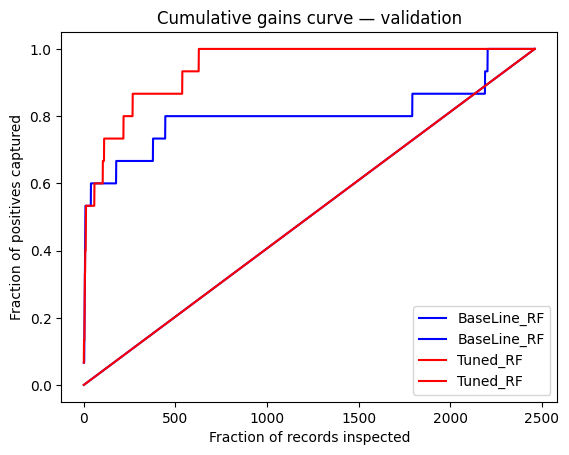

In [36]:
import matplotlib.pyplot as plt
import numpy as np


baseline_gain_valid = cumulative_gain_frame(y_valid, baseline_valid_scores)
tuned_gain_valid = cumulative_gain_frame(y_valid, tuned_valid_scores)
'''
ax1 = baseline_gain_valid.plot(
    x="inspected_fraction",
    y="cumulative_capture_rate",
    legend=False,
    title="Cumulative gains curve — validation — Baseline Random Forest",
)

ax2 = tuned_gain_valid.plot(
    x="inspected_fraction",
    y="cumulative_capture_rate",
    legend=False,
    title="Cumulative gains curve — validation — Tuned Random Forest",
)
'''


plt.plot(baseline_gain_valid, label = 'BaseLine_RF', color = 'blue')
plt.plot(tuned_gain_valid,    label = "Tuned_RF", color = 'red')


plt.legend(loc="lower right")

plt.xlabel("Fraction of records inspected")
plt.ylabel("Fraction of positives captured")
plt.title('Cumulative gains curve — validation')
plt.show()

## What is the Cumulative Gains Curve?

AI Overview                 

A cumulative gains curve is a vital evaluation tool used in binary classification to visualize how effectively a predictive model identifies targets compared to random selection. 

It plots the cumulative percentage of true positive targets captured (y-axis) against the cumulative percentage of the population contacted or scored (x-axis).To grasp its business and data science value, understanding a few core elements is key:

How it WorksSorting: The dataset is ordered by the model’s predicted probability of a positive outcome (e.g., customer response or loan default), from highest to lowest.Cumulative Capture: 

The curve plots what percentage of the total actual targets are captured when looking down through this ranked list. For example, the point (10, 30) on the curve means contacting the top 10% of the ranked population catches 30% of all true positive targets.

The Three Key LinesA standard cumulative gains plot contains three primary curves that act as reference points:

The Baseline (Random Model): A straight diagonal line representing random targeting. If you contact X% of the population blindly, you can expect to capture X% of the total targets.

The Predictive Model Curve: The curved line mapping your actual model's performance. It should arch significantly above the baseline towards the top-left corner.

The Optimal Model: The theoretical "perfect" model. This curve shoots straight up to 100% of the targets as quickly mathematically possible (e.g., taking exactly 10% of the population if 10% of the total dataset are positives).

## 15. Final test evaluation = final_model

Only run this after you have finished choosing the model using the validation set.

Do not tune the model again after looking at the test results.

In [40]:
final_model = best_rf

test_scores = get_scores(final_model, X_test)

print("Final tuned Random Forest — test")
print(f"ROC-AUC:           {roc_auc_score(y_test, test_scores):.3f}")
print(f"Average Precision: {average_precision_score(y_test, test_scores):.3f}")

test_top_k = top_k_capture_table(y_test, test_scores, TOP_K_VALUES, label="test")
display(test_top_k)


Final tuned Random Forest — test
ROC-AUC:           0.830
Average Precision: 0.386


,dataset,k,positives_in_top_k,precision_at_k,recall_at_k,max_possible_recall_at_k,pct_of_max_possible_recall,lift_at_k
0,test,50,7,0.140,0.466667,1.0,0.466667,22.988
1,test,100,9,0.090,0.600000,1.0,0.600000,14.778
2,test,200,9,0.045,0.600000,1.0,0.600000,7.389
3,test,500,10,0.020,0.666667,1.0,0.666667,3.284


## 16. Create a ranked test output

This creates a table sorted from highest predicted risk to lowest predicted risk.

The top rows are the records the organisation would prioritise for inspection or intervention.

In [42]:
ids_test[:5]

,Addressbase UPRN,LSOA11CD
234246,100120792099,E01028490
160616,100120789353,E01028490
140647,100120789156,E01028491
195290,100120803416,E01028498
114632,100120794815,E01028493


In [48]:
ranked_test = ids_test.copy()
ranked_test["true_target"] = y_test.values
ranked_test["risk_score"] = test_scores
ranked_test["risk_rank"] = ranked_test["risk_score"].rank(method="first", ascending=False).astype(int)

ranked_test = ranked_test.sort_values("risk_score", ascending=False)

display(ranked_test.head(10))

# Save outputs for reporting.
ranked_test.to_csv("ranked_test_output.csv", index=False)
#ranked_test.head(50).to_csv("top_50_ranked_test_output.csv", index=False)

#print("Saved ranked_test_output.csv")
#print("Saved top_50_ranked_test_output.csv")

,Addressbase UPRN,LSOA11CD,true_target,risk_score,risk_rank
17464,10011922552,E01028491,1,0.974308,1
17463,10011922552,E01028491,1,0.974308,2
112508,10011889050,E01028511,0,0.959939,3
125702,10011913940,E01028512,1,0.956806,4
226937,10011925484,E01028511,1,0.928622,5
150190,10011914232,E01028512,1,0.921873,6
232742,10011873750,E01028488,1,0.921494,7
157756,10011913856,E01028495,0,0.844739,8
61763,100121291714,E01028498,0,0.798696,9
191975,10011910354,E01028495,0,0.791554,10


## 17. How to explain low recall@50

Use this explanation if your top-50 recall looks low.

Recall@50 is calculated as:

```text
true positives in top 50 / all true positives in the dataset
```

So if the top 50 contains 38 true positives, precision is high:

```text
precision@50 = 38 / 50 = 0.76
```

But recall may still look low if there are many positives overall. For example, if there are 200 positives:

```text
recall@50 = 38 / 200 = 0.19
```

That does not mean the model is useless. It means top 50 is too small to capture most positives.

That is why this notebook also reports:

```text
pct_of_max_possible_recall
```

This shows how close the model is to the best possible result for that value of K.

## 18. Interpretation prompts

Answer these in markdown after running the notebook.

1. What is the positive class and why is the problem imbalanced?
2. Why is accuracy not enough for this task?
3. What was the validation ROC-AUC?
4. What was the validation Average Precision?
5. In the validation top 50, how many true positives were captured?
6. What was precision@50?
7. What was recall@50?
8. What percentage of the maximum possible recall@50 did the model achieve?
9. Did tuning improve the baseline Random Forest?
10. Based on the test results, should the organisation use top 50, top 100, or top 200?
11. What extra data might improve the ranking?
12. What are the limitations of using this model operationally?

Suggested conclusion structure:

> The model should be used as a prioritisation tool, not as an automatic decision-maker. The most useful metric is whether the top-ranked records contain more true incidents than random selection. The final top-K results suggest that [...]. However, the model is limited by [...], so future work should [...].

# RESPONSES:

1. What is the positive class and why is the problem imbalanced?
   The positive class is the represented by "1" the binary output of [0,1]
   Which is attributed to the class of an event, in this case an "incident", occuring => 1
   The class attributed to the class of an event, in this case an "incident", NOT  occuring => 0

   Since we are dealing with the whether an incident will occur, output = 1, being extremely rare event within a very large dataset,    the distributions of 0 and 1 are inbalanced. Such as proprtion(0) = 0.99, proportion(1) = 0.01

   ### From Google AI:
   
  Unbalanced (or imbalanced) data in machine learning occurs when one class significantly outnumbers the other(s) in a dataset. For example, in a credit card fraud detection dataset, 99% of transactions might be legitimate (the majority class), while only 1% are fraudulent (the minority class).
Because machine learning algorithms inherently try to maximize overall accuracy, an unbalanced dataset can cause a model to simply guess the majority class every time. This results in high numerical accuracy but terrible performance on the rare, often critical events.

Why It's a ProblemMisleading Metrics: A model predicting 100% legitimate transactions in the example above achieves 99% accuracy, completely failing to catch the 1% fraud.Class Bias: The algorithm never learns the true characteristics of the minority group, leading to high false-negative rates

Work around:
Using the Right Evaluation Metrics: Instead of relying on raw accuracy, you should evaluate model performance using metrics designed for imbalanced data, such as Precision, Recall, F1-Score, or the ROC-AUC curve.
https://www.youtube.com/watch?v=6kwEbsCiLg8

2. Why is accuracy not enough for this task?
Accuracy will suffer from skewing as a result of the raw data being skewed.
If 99% of targets belong to class A, then the model can easily "guess" the prediction as A, by simply saying the target is A will be correct 99/100 guesses
By means of the standard accuracy metric: (TP + TN) / Total === (99 + 0)/100  = 0.99
This masks the models detection of the minority class, such a A = 99, B = 1, it will be difficult to identify class B

Prefered metrics: 
PRECISION: number of pred(+) are actual(+)
RECALL: number of  actual(+) are pred(+)      --- High Recall catches most cases, but may include some FP
High FP - suitable for our task since we are assessing for prevention of incidents, so FP creeping in will have no serious impact/
F1:   denotes balance between PRECISION and RECALL
ROC-AUC

# Join to geospatial data for mapping and standard analysis methods
## Not essential for ML model

In [49]:
### Extra part.
#### Join geolocation result:
Gazetter = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/Documents for June 2026/OXFORDSHIRE_GAZETTER.xlsx')
Gazetter = pd.DataFrame(Gazetter)
Gazetter.drop(columns = ['BUILDINGNAME' , 'BUILDINGNUMBER'])
Gazetter.head(2)

,FCL_URN,BUILDINGNAME,BUILDINGNUMBER,STREETNAME1,STREETNAME2,AREANAME1,AREANAME2,POSTCODE,POSTTOWN,POSTCOUNTY,ACTUALX,ACTUALY
0,10002187000,SHIPTON COURT,NaN,HIGH STREET,NaN,NaN,SHIPTON UNDER WYCHWOOD,OX7 6DG,NaN,OXFORDSHIRE,427767.0,217531.0
1,10002187001,SHIPTON COURT,NaN,HIGH STREET,NaN,NaN,SHIPTON UNDER WYCHWOOD,OX7 6DG,NaN,OXFORDSHIRE,427767.0,217531.0


In [77]:
ranked_geolocs = Gazetter.merge(ranked_test, left_on = 'FCL_URN', right_on = 'Addressbase UPRN', how = 'right')
ranked_geolocs.drop(columns = ['BUILDINGNAME' , 'BUILDINGNUMBER'], inplace = True)
ranked_geolocs.sample(5) 

,FCL_URN,STREETNAME1,STREETNAME2,AREANAME1,AREANAME2,POSTCODE,POSTTOWN,POSTCOUNTY,ACTUALX,ACTUALY,Addressbase UPRN,LSOA11CD,true_target,risk_score,risk_rank
1900,100120791206,HARDWICK AVENUE,NaN,NaN,KIDLINGTON,OX5 1BH,NaN,OXFORDSHIRE,449387.0,213262.0,100120791206,E01028492,0,0.003973,1579
1903,100120791775,LANE CLOSE,NaN,NaN,KIDLINGTON,OX5 1BA,NaN,OXFORDSHIRE,448594.0,213778.0,100120791775,E01028494,0,0.003938,1582
1908,100120790010,CROMWELL WAY,NaN,NaN,KIDLINGTON,OX5 2LN,NaN,OXFORDSHIRE,450077.0,213253.0,100120790010,E01028511,0,0.003898,1587
2418,100120824721,KENDALL CRESCENT,NaN,NaN,OXFORD,OX2 8NF,NaN,OXFORDSHIRE,450810.0,210265.0,100120824721,E01028597,0,0.000584,2041
494,10011890248,BLACKBULL LANE,NaN,NaN,FENCOTT,OX5 2RD,NaN,OXFORDSHIRE,457539.0,216213.0,10011890248,E01028501,0,0.114199,366


In [51]:
ranked_geolocs_area = ranked_geolocs[['AREANAME2']].value_counts()
areas = pd.DataFrame(ranked_geolocs_area)
#areas.to_csv(f'H:/OXFS Share/AdamMason/PROJECTS/C_SPark_Home_Safety/Ranked_Property_STATIONS/ranked_areas{Station_Ground_Code}.csv')
areas

,count
AREANAME2,
KIDLINGTON,1586
YARNTON,399
BLETCHINGDON,143
OXFORD,122
TACKLEY,103
KIRTLINGTON,90
BEGBROKE,75
GOSFORD,59
ISLIP,59


In [52]:
ranked_geolocs.to_csv(f'H:/OXFS Share/AdamMason/PROJECTS/C_SPark_Home_Safety/Ranked_Property_STATIONS/ranked_geolocs_for_map_{Station_Ground_Code}.csv')
#streets.to_excel(f'H:/OXFS Share/AdamMason/PROJECTS/C_SPark_Home_Safety/Ranked_Property_STATIONS/ranked_streets{Station_Ground_Code}.xlsx')
#streets.to_csv(f'H:/OXFS Share/AdamMason/PROJECTS/C_SPark_Home_Safety/Ranked_Property_STATIONS/ranked_streets{Station_Ground_Code}.csv')

# 16. Testing:

In [53]:
from sklearn.metrics import precision_score, roc_auc_score, mean_squared_error, accuracy_score
from sklearn.metrics import recall_score, classification_report, roc_curve, confusion_matrix
from sklearn import metrics

### TRAINING DATA

In [54]:
# Model Performance
# we can get performance of the model on the TRAIN data set from 
y_train_pred_best_rf =  best_rf.predict(X_train)
y_train_pred_best_rf

array([0, 0, 0, ..., 0, 0, 0], shape=(7389,))

In [80]:
## 5. Evaluate on TRAINING SET: 
from sklearn.metrics import classification_report
target_names = ['0', '1']
print("TUNED MODEL: \nbest_rf(X_train)\n\nClassification Report:")
print(classification_report(y_train, y_train_pred_best_rf, target_names=target_names))

TUNED MODEL: 
best_rf(X_train)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      7343
           1       0.28      1.00      0.44        46

    accuracy                           0.98      7389
   macro avg       0.64      0.99      0.72      7389
weighted avg       1.00      0.98      0.99      7389



## TEST DATA

In [81]:
# 5. Evaluate on TEST SET: 
y_test_pred_best_rf = best_rf.predict(X_test)
y_test_pred_best_rf

target_names = ['0', '1']
print("TUNED MODEL: \nbest_rf(X_test)\n\nClassification Report:")
print(classification_report(y_test, y_test_pred_best_rf, target_names=target_names))

TUNED MODEL: 
best_rf(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2448
           1       0.16      0.47      0.23        15

    accuracy                           0.98      2463
   macro avg       0.58      0.73      0.61      2463
weighted avg       0.99      0.98      0.99      2463



## Accuracy Scores:

In [82]:
best_rf_pred_RF_ACCURACY =  metrics.accuracy_score( y_train,  y_train_pred_best_rf)
best_rf_pred_RF_PRECISION = metrics.precision_score(y_train,  y_train_pred_best_rf)
best_rf_pred_RF_RECALL =    metrics.recall_score(   y_train,  y_train_pred_best_rf)
best_rf_pred_RF_PF1 =       metrics.f1_score(       y_train,  y_train_pred_best_rf)

In [83]:
d = {"accuracy_score":  [metrics.accuracy_score(y_train, y_train_pred_best_rf),  metrics.accuracy_score( y_test, y_test_pred_best_rf)], 
     "precision_score": [metrics.precision_score(y_train, y_train_pred_best_rf), metrics.precision_score(y_test, y_test_pred_best_rf)],
     "recall_score":    [metrics.recall_score(y_train, y_train_pred_best_rf),    metrics.recall_score(   y_test, y_test_pred_best_rf)],
     "f1_score":        [metrics.f1_score(y_train, y_train_pred_best_rf),        metrics.f1_score(       y_test, y_test_pred_best_rf)]    
    }
print("RANDOM FOREST baseline: With respect to target variable = 1\n")
RF_metrics = pd.DataFrame(data=d, index=['TRAIN', 'TEST'])
RF_metrics = RF_metrics.T
RF_metrics


RANDOM FOREST baseline: With respect to target variable = 1



,TRAIN,TEST
accuracy_score,0.984166,0.981324
precision_score,0.282209,0.155556
recall_score,1.000000,0.466667
f1_score,0.440191,0.233333


<Figure size 1000x500 with 0 Axes>

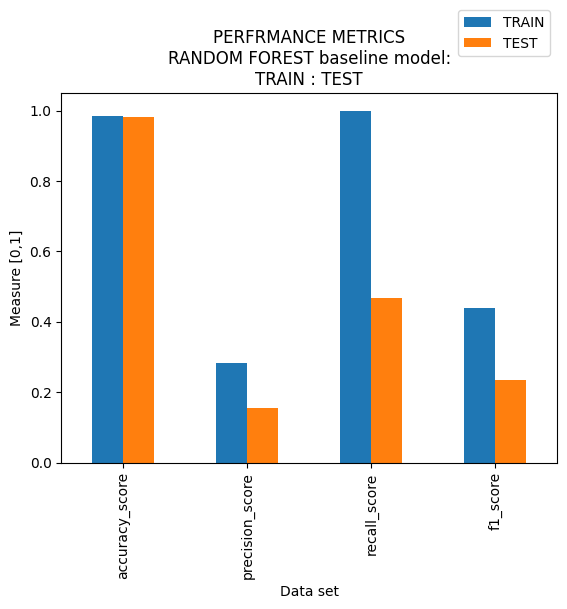

In [84]:
plt.figure(figsize = (10,5))
#RF_metrics[['accuracy_score','precision_score']].plot(kind = 'bar', legend = True)
#RF_metrics[['recall_score',	'f1_score']].plot(kind = 'bar', legend = True)

RF_metrics[['TRAIN','TEST']].plot(kind = 'bar', legend = True)
plt.title("PERFRMANCE METRICS\nRANDOM FOREST baseline model:\nTRAIN : TEST") 
#plt.legend(loc = " right")
plt.legend(loc=(0.8,1.1))
plt.xlabel('Data set')
plt.ylabel('Measure [0,1]')
plt.show()

## ROC metrics

TEST data Prediction Probabilities:

## BASELINE

In [85]:
y_test_pred_proba_baseline_rf =  baseline_rf.predict_proba(X_test)[:,1]
y_test_pred_proba_baseline_rf

array([0.        , 0.        , 0.        , ..., 0.        , 0.        ,
       0.03666667], shape=(2463,))

In [86]:
logit_roc_auc_baseline        = roc_auc_score(y_test,    y_test_pred_proba_baseline_rf)
print(f'ROC-AUC_score[y_test]: {logit_roc_auc_baseline}')

ROC-AUC_score[y_test]: 0.7192265795206971


In [87]:
fpr_baseline_rf, tpr_baseline_rf, thresholds = roc_curve(y_test,    y_test_pred_proba_baseline_rf)

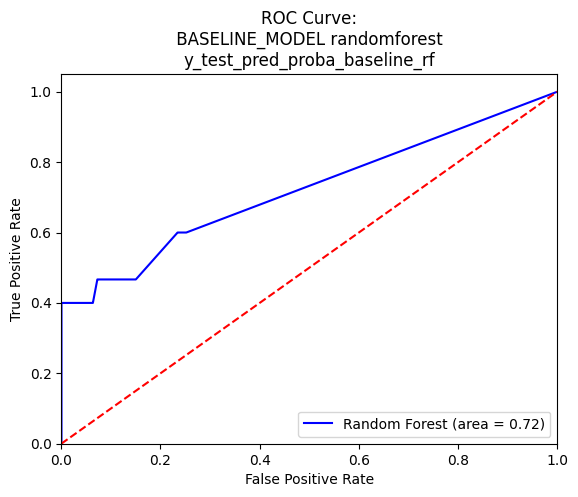

In [98]:

plt.figure()
plt.plot(fpr_baseline_rf, tpr_baseline_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_baseline,color = 'blue' )
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve:\n BASELINE_MODEL randomforest \ny_test_pred_proba_baseline_rf')
plt.legend(loc="lower right")
plt.show()


In [90]:
x = RF_metrics.T['precision_score'][1:][0:] 
#y = RF_metrics['precision_score'][0:][0:]



TEST    0.155556
Name: precision_score, dtype: float64

## TUNED ROC:  
#### logit_roc_auc_best_rf

In [91]:
y_test_pred_proba_best_rf =  best_rf.predict_proba(X_test)[:,1]
y_test_pred_proba_best_rf

array([0.06110897, 0.00192315, 0.00075782, ..., 0.00946461, 0.0153257 ,
       0.29992346], shape=(2463,))

In [92]:
logit_roc_auc_best_rf       = roc_auc_score(y_test,    y_test_pred_proba_best_rf)
print(f'ROC-AUC_score[y_test]: {logit_roc_auc_best_rf}')

ROC-AUC_score[y_test]: 0.8296840958605665


In [93]:
fpr_best_rf, tpr_best_rf, thresholds = roc_curve(y_test,    y_test_pred_proba_best_rf)

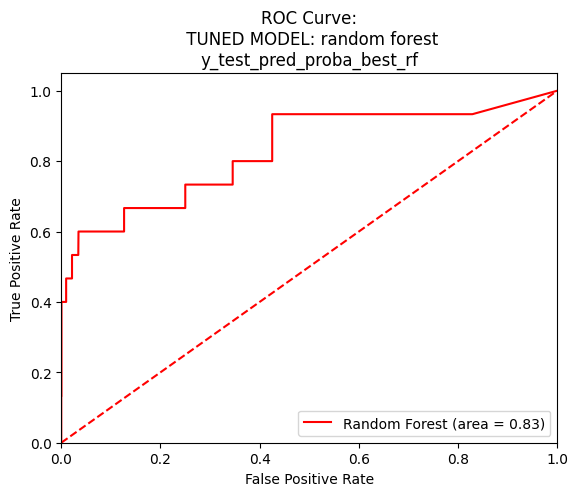

In [100]:

plt.figure()
plt.plot(fpr_best_rf, tpr_best_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_best_rf, color = 'red')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve:\n TUNED MODEL: random forest\ny_test_pred_proba_best_rf')
plt.legend(loc="lower right")
plt.show()


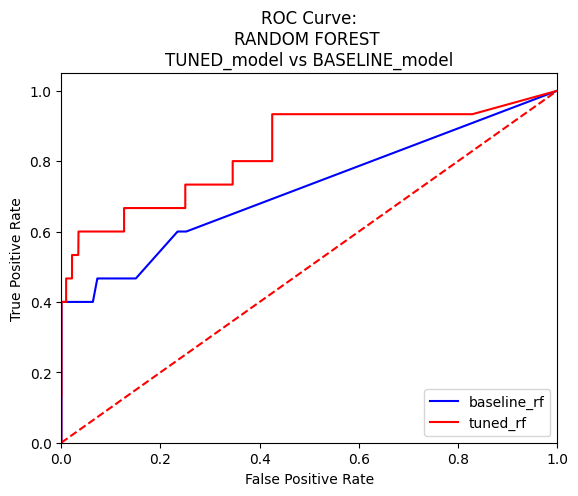

In [102]:

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve:\nRANDOM FOREST \nTUNED_model vs BASELINE_model')


plt.plot(fpr_baseline_rf, tpr_baseline_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_baseline, color = 'blue')
plt.plot(fpr_best_rf, tpr_best_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_best_rf, color = 'red')
plt.plot([0, 1], [0, 1],'r--')

plt.legend(labels = ['baseline_rf','tuned_rf'], loc="lower right")
plt.show()

In [103]:
data = {
  "Baseline_ROC_Score": logit_roc_auc_baseline,
  "Tuned_RF_ROC_Score": logit_roc_auc_best_rf
}
data



{'Baseline_ROC_Score': 0.7192265795206971,
 'Tuned_RF_ROC_Score': 0.8296840958605665}

In [104]:
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['ABP_Classification_Desc','Communal Household Flag','(H) Age - Fine',..., '(H) Number of Children v3','(H) Household Income v3 - Bands', 'Station_Ground_Code']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcol

### feature importance

In [105]:
best_pipeline=rf_search.best_estimator_ 
print(best_pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Communal Household Flag', '(H) Age - Fine',
                                  '(H) Household Composition',
                                  '(H) Presence of Elderly Parent',
                                  '(H) Number of Adults in Household',
                                  '(H) Family Lifestage v3',
                                  '(H) Length of Residency', '(H) Tenure 2011',
                                  '(H) Affluence v2', '(H) Water Poverty Flag',
                                  '(H) Fuel Poverty v2 Flag',
                                  '(H) Number of Children v3',
                                  '(H) Household Income v3 - Bands']),
                  

In [106]:
rf_model = best_pipeline.named_steps["model"]
feature_importances = rf_model.feature_importances_

In [107]:
#feature_importances

Number of transformed features: 71
Number of importances: 71


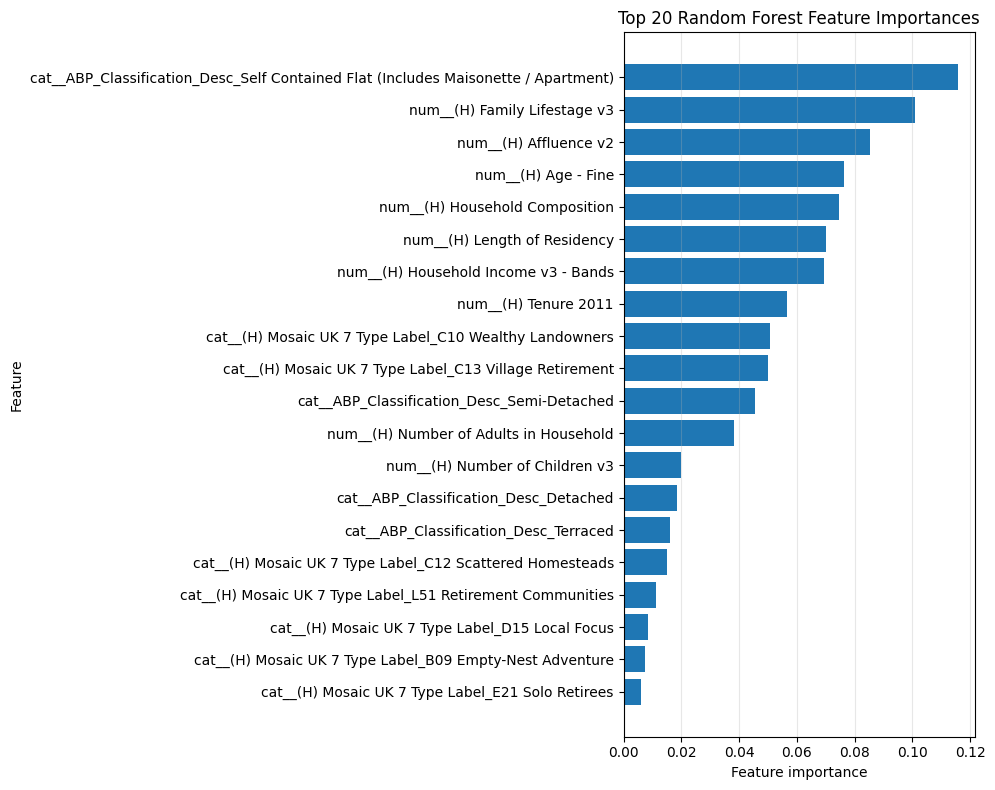

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
rf_model = best_pipeline.named_steps["model"]
feature_importances = rf_model.feature_importances_
preprocessor = best_pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
print("Number of transformed features:", len(feature_names))
print("Number of importances:", len(feature_importances))
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values("Importance", ascending=False)
top_features = importance_df.head(20).sort_values("Importance")
plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
 
 

In [109]:
importance_df

,Feature,Importance
17,cat__ABP_Classification_Desc_Self Contained Fl...,0.115795
5,num__(H) Family Lifestage v3,0.100738
8,num__(H) Affluence v2,0.085299
1,num__(H) Age - Fine,0.076332
2,num__(H) Household Composition,0.074754
...,...,...
56,cat__(H) Mosaic UK 7 Type Label_K44 Inner City...,0.000000
61,cat__(H) Mosaic UK 7 Type Label_M54 Down-to-Ea...,0.000000
60,cat__(H) Mosaic UK 7 Type Label_L53 Seasoned S...,0.000000
68,cat__(H) Mosaic UK 7 Type Label_O63 Flexible W...,0.000000


### What is a Random Forest?
### It is a collection of Decsion Trees.
### One such Decision Tree can be pulled out at random from the Random Forest Algorithm for display:

In [111]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

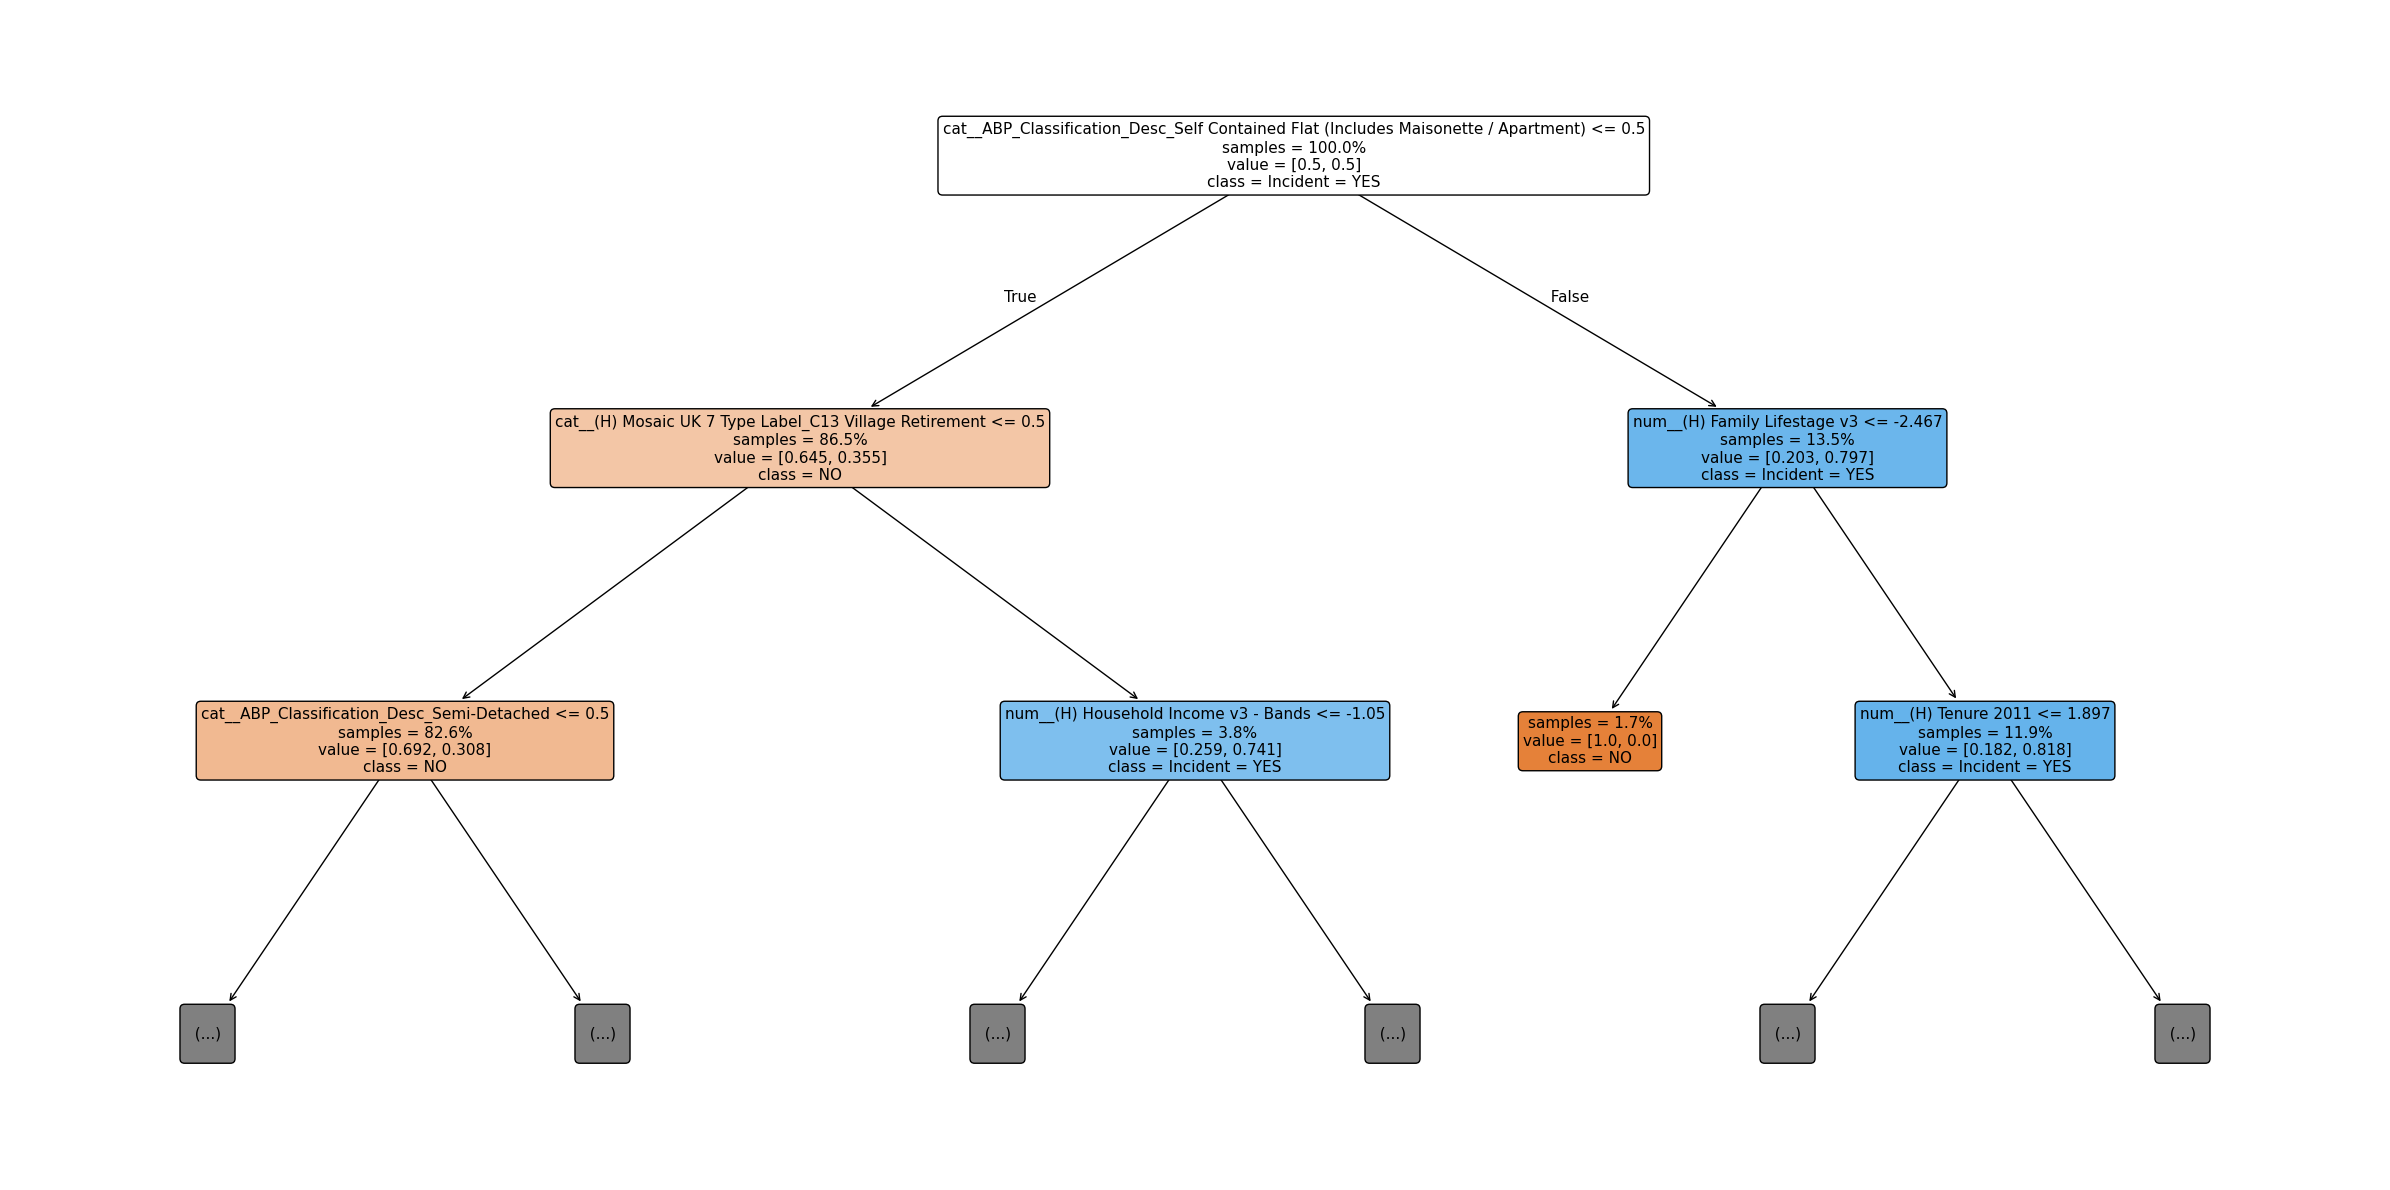

In [112]:
rf_model = best_rf.named_steps["model"]
example_tree = rf_model.estimators_[0]

plt.figure(figsize=(24, 12))
plot_tree(
    example_tree,
    max_depth=2,
    feature_names=feature_names,
    class_names=["NO", "Incident = YES"],
    filled=True,
    impurity=False,
    proportion=True,
    rounded=True,
    fontsize=11
)
plt.tight_layout()
plt.savefig("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/Documents for June 2026/images/DecsionTree_example.svg")#, bbox_inches="tight")
plt.show()